In [1]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve, precision_score, recall_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
data_path = 'data'
path = Path(data_path)

data = []

columns = [
    "compactness",
    "circularity",
    "distance_circularity",
    "radius_ratio",
    "pr_axis_aspect_ratio",
    "max_length_aspect_ratio",
    "scatter_ratio",
    "elongatedness",
    "pr_axis_rectangularity",
    "max_length_rectangularity",
    "scaled_variance_major_axis",
    "scaled_variance_minor_axis",
    "scaled_radius_of_gyration",
    "skewness_major_axis",
    "skewness_minor_axis",
    "kurtosis_major_axis",
    "kurtosis_minor_axis",
    "hollows_ratio",
    'label'
]

for file in path.iterdir():
    if file.is_file():
        text_lines = pd.read_csv(file, header=None).values.tolist()

        for line in text_lines:
            data.append(line[0].strip().split(' '))

data = pd.DataFrame(data, columns=columns)

Y = data['label']
X = data.drop('label', axis=1)

<Axes: >

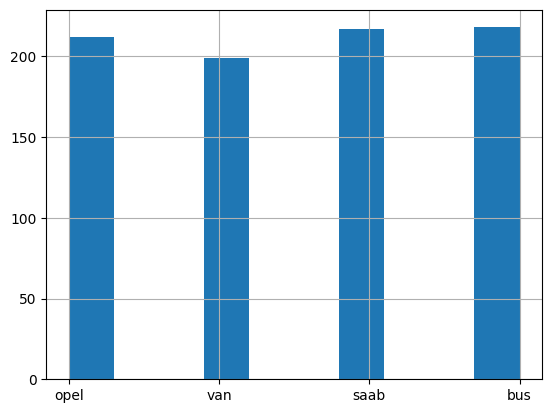

In [3]:
Y.hist()

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42, stratify=Y)

In [5]:
def draw_some_metrics(best_estimator):
    probas = best_estimator.predict_proba(X_train)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(Y_train, probas)

    plt.plot(thresholds, precisions[:-1], label="Precision")
    plt.plot(thresholds, recalls[:-1], label="Recall")
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xlabel("Thresholds")
    plt.legend()
    plt.show()

    plt.plot(recalls, precisions)
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.show()
    
    fpr, tpr, _ = roc_curve(Y_train, probas)

    plt.plot(fpr, tpr, label="Precision")
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xlabel("% negatywnych przypadków jako pozytywne")
    plt.ylabel("% pozytywnych przypadków jako pozytywne")
    plt.title("ROC")
    plt.show()

In [6]:
preprocessing = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
preprocessing

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a f

In [7]:
pd.DataFrame(preprocessing.fit_transform(X_train), columns=preprocessing.get_feature_names_out())

,compactness,circularity,distance_circularity,radius_ratio,pr_axis_aspect_ratio,max_length_aspect_ratio,scatter_ratio,elongatedness,pr_axis_rectangularity,max_length_rectangularity,scaled_variance_major_axis,scaled_variance_minor_axis,scaled_radius_of_gyration,skewness_major_axis,skewness_minor_axis,kurtosis_major_axis,kurtosis_minor_axis,hollows_ratio
0,1.354660,1.120776,1.574700,1.090178,-0.229116,0.443770,1.451987,-1.261956,1.290219,1.265117,1.003129,1.446807,0.663722,-0.860847,-1.298574,0.827449,0.358137,1.000729
1,-0.314176,0.157506,1.193064,0.857391,0.358504,0.053548,0.796106,-0.878715,0.908512,-0.165959,0.940275,0.736634,0.724956,0.037446,-0.288890,-0.546755,-0.448180,-0.199641
2,-0.433378,-0.324129,-0.079056,1.788538,4.119276,7.272661,-0.575284,0.526503,-0.618318,0.038480,0.343167,-0.616610,-0.346639,2.347341,-0.288890,-0.432238,-0.448180,0.067108
3,-1.029391,-0.966309,-0.905934,-1.470476,-1.169309,-0.726897,-1.231166,1.548480,-1.000025,-0.915571,-1.291026,-1.125475,-1.020212,0.294101,0.316919,-0.546755,-1.093234,-1.133262
4,-0.194973,-1.447944,-0.269874,-0.131952,-0.581689,-0.141563,-0.485845,0.271009,-0.618318,-1.392596,-0.631064,-0.521548,-1.571318,-1.630812,-0.490827,0.712932,2.293298,2.067725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629,-0.552581,-0.163584,-0.397086,-1.295886,-0.934261,0.248659,-0.396407,0.398756,-0.236610,0.174773,-0.819624,-0.504772,0.020765,0.422428,1.124666,-0.088687,-0.770707,-0.333015
630,1.593065,1.441866,1.002246,0.973785,0.358504,0.443770,1.451987,-1.261956,1.671927,1.265117,1.254543,1.418848,1.245445,-0.090882,-1.096637,1.743585,-0.286917,0.467231
631,-1.029391,-0.966309,-1.605601,-1.266787,-0.699213,-0.531786,-1.648545,2.187216,-1.381733,-0.915571,-1.731001,-1.382703,-0.928361,-1.117502,2.134349,-0.661272,1.325718,0.867355
632,-1.148594,-0.324129,-0.397086,0.304523,1.533745,-0.336674,-0.426220,0.271009,-0.618318,-0.370399,-0.285369,-0.465629,-0.071086,0.550756,-0.288890,-0.088687,-0.609444,-0.733139


### Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression

lr_classifier = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42)),
])

lr_classifier

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: s

In [9]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    "classifier__tol": [1e-2, 1e-3, 1e-1, 1e-4],
    "classifier__C": [1, 1e-1, 10, 100],
}

lr_searching = GridSearchCV(lr_classifier, lr_params, scoring="accuracy", cv=5)
lr_searching.fit(X_train, Y_train)

print(lr_searching.best_params_)
pd.DataFrame(lr_searching.cv_results_).sort_values(by="mean_test_score", ascending=False)[:5]

{'classifier__C': 100, 'classifier__tol': 0.0001}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__C,param_classifier__tol,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
15,0.037442,0.001904,0.001996,0.000101,100.0,0.0001,"{'classifier__C': 100, 'classifier__tol': 0.0001}",0.834646,0.795276,0.771654,0.795276,0.849206,0.809211,0.028445,1
13,0.015933,0.000740,0.001804,0.000030,100.0,0.0010,"{'classifier__C': 100, 'classifier__tol': 0.001}",0.834646,0.803150,0.771654,0.795276,0.825397,0.806024,0.022359,2
9,0.013372,0.001172,0.001848,0.000071,10.0,0.0010,"{'classifier__C': 10, 'classifier__tol': 0.001}",0.826772,0.787402,0.771654,0.787402,0.817460,0.798138,0.020617,3
11,0.026212,0.001766,0.002270,0.000224,10.0,0.0001,"{'classifier__C': 10, 'classifier__tol': 0.0001}",0.826772,0.779528,0.779528,0.787402,0.809524,0.796550,0.018681,4
1,0.011337,0.000696,0.001949,0.000159,1.0,0.0010,"{'classifier__C': 1, 'classifier__tol': 0.001}",0.811024,0.771654,0.771654,0.779528,0.746032,0.775978,0.020857,5


In [10]:
best_estimator = lr_searching.best_estimator_
preds = best_estimator.predict(X_test)

print(f"Accuracy: {accuracy_score(Y_test, preds)}")
print(f"Recall: {recall_score(Y_test, preds, average='weighted')}")
print(f"Precision: {precision_score(Y_test, preds, average='weighted')}")

Accuracy: 0.7783018867924528
Recall: 0.7783018867924528
Precision: 0.7772377053348929


### Random Forest

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", RandomForestClassifier(n_jobs=-1)),
])

rf_classifier

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: s

In [12]:
rf_params = {
    "classifier__max_depth": [None, 10],
    "classifier__max_features": [None, 5, 10],
    "classifier__n_estimators": [50, 100, 150],
}

rf_searching = GridSearchCV(rf_classifier, rf_params, scoring="accuracy", cv=5)
rf_searching.fit(X_train, Y_train)

print(rf_searching.best_params_)
pd.DataFrame(rf_searching.cv_results_).sort_values(by="mean_test_score", ascending=False)[:5]

{'classifier__max_depth': None, 'classifier__max_features': 10, 'classifier__n_estimators': 50}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__max_depth,param_classifier__max_features,param_classifier__n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,0.096310,0.007096,0.018717,0.004606,None,10,50,"{'classifier__max_depth': None, 'classifier__m...",0.740157,0.771654,0.779528,0.771654,0.825397,0.777678,0.027426,1
3,0.090160,0.002011,0.016394,0.000506,None,5,50,"{'classifier__max_depth': None, 'classifier__m...",0.779528,0.755906,0.763780,0.771654,0.801587,0.774491,0.015670,2
9,0.097978,0.004661,0.019352,0.005454,10,None,50,"{'classifier__max_depth': 10, 'classifier__max...",0.740157,0.779528,0.755906,0.755906,0.825397,0.771379,0.029793,3
14,0.239368,0.002533,0.036729,0.000357,10,5,150,"{'classifier__max_depth': 10, 'classifier__max...",0.763780,0.724409,0.779528,0.787402,0.801587,0.771341,0.026456,4
7,0.172146,0.003489,0.027021,0.000602,None,10,100,"{'classifier__max_depth': None, 'classifier__m...",0.740157,0.740157,0.763780,0.787402,0.817460,0.769791,0.029580,5


In [13]:
best_estimator = rf_searching.best_estimator_
preds = best_estimator.predict(X_test)

print(f"Accuracy: {accuracy_score(Y_test, preds)}")
print(f"Recall: {recall_score(Y_test, preds, average='weighted')}")
print(f"Precision: {precision_score(Y_test, preds, average='weighted')}")

Accuracy: 0.7075471698113207
Recall: 0.7075471698113207
Precision: 0.6985374862733353


### MLEM2

In [14]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from mlem2 import MLEM2

mlem2_classifier = MLEM2()

In [15]:
preprocessing.fit(X_train)
X_train_preprocessed = preprocessing.transform(X_train)
X_test_preprocessed = preprocessing.transform(X_test)

In [16]:
mlem2_classifier.fit(pd.DataFrame(X_train_preprocessed, columns=columns[:-1]), Y_train, only_certain=False)


Train process:
	1/4 label (opel)	Covered in 28 iterations (6.36 s)
	2/4 label (van)	Covered in 9 iterations (1.91 s)
	3/4 label (saab)	Covered in 24 iterations (5.33 s)
	4/4 label (bus)	Covered in 7 iterations (1.24 s)



[[['max_length_rectangularity', '>=', 1.844362422369, 'opel'],
  ['scaled_variance_minor_axis', '>=', 1.561441414514, 'opel']],
 [['hollows_ratio', '>=', -0.266328241234, 'opel'],
  ['compactness', '<', 1.53346362222, 'opel'],
  ['scaled_radius_of_gyration', '>=', 0.862732943041, 'opel'],
  ['skewness_major_axis', '>=', -0.155045554419, 'opel'],
  ['skewness_minor_axis', '>=', -0.995668599609, 'opel'],
  ['scaled_variance_minor_axis', '>=', 1.337764731228, 'opel']],
 [['scatter_ratio', '>=', 1.466893866219, 'opel'],
  ['compactness', '<', 1.53346362222, 'opel'],
  ['max_length_rectangularity', '>=', 1.571776426499, 'opel'],
  ['distance_circularity', '>=', 1.288473372441, 'opel']],
 [['compactness', '<', 1.414261079738, 'opel'],
  ['max_length_rectangularity', '>=', 1.29919043063, 'opel'],
  ['compactness', '>=', 0.341438197395, 'opel'],
  ['scaled_variance_major_axis', '<', 1.113122481768, 'opel'],
  ['scaled_radius_of_gyration', '<', 1.352604925924, 'opel']],
 [['distance_circularity

In [17]:
preds = mlem2_classifier.predict(pd.DataFrame(X_test_preprocessed, columns=columns[:-1]))

print(f"Accuracy: {accuracy_score(Y_test, preds)}")
print(f"Recall: {recall_score(Y_test, preds, average='weighted')}")
print(f"Precision: {precision_score(Y_test, preds, average='weighted')}")


During the prediction, 45 conflicts occurred.
The prediction process included 14 objects whose class could not be predicted.

Accuracy: 0.6273584905660378
Recall: 0.6273584905660378
Precision: 0.6188758044515442


In [18]:
mlem2_classifier.print_rules()

1) 'max_length_rectangularity >= 1.844362422369' && 'scaled_variance_minor_axis >= 1.561441414514' => 'label=opel'
2) 'hollows_ratio >= -0.266328241234' && 'compactness < 1.53346362222' && 'scaled_radius_of_gyration >= 0.862732943041' && 'skewness_major_axis >= -0.155045554419' && 'skewness_minor_axis >= -0.995668599609' && 'scaled_variance_minor_axis >= 1.337764731228' => 'label=opel'
3) 'scatter_ratio >= 1.466893866219' && 'compactness < 1.53346362222' && 'max_length_rectangularity >= 1.571776426499' && 'distance_circularity >= 1.288473372441' => 'label=opel'
4) 'compactness < 1.414261079738' && 'max_length_rectangularity >= 1.29919043063' && 'compactness >= 0.341438197395' && 'scaled_variance_major_axis < 1.113122481768' && 'scaled_radius_of_gyration < 1.352604925924' => 'label=opel'
5) 'distance_circularity >= 1.224867352187' && 'max_length_rectangularity < 1.094750933727' && 'pr_axis_aspect_ratio >= 0.534790351911' && 'skewness_minor_axis >= -0.591795348072' => 'label=opel'
6) 'co

### LEM2

In [19]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from lem2_numpy import LEM2
from discretizer import Discretizer

lem2_classifier = LEM2()

In [20]:
preprocessing.fit(X_train)
X_train_preprocessed = pd.DataFrame(preprocessing.transform(X_train), columns=columns[:-1])
X_test_preprocessed = pd.DataFrame(preprocessing.transform(X_test), columns=columns[:-1])


discretizer = Discretizer()
discretizer.fit(X_train_preprocessed, attributes=columns[:-1], number_of_output_values=7, distance_from_extreme_values=0.1)
X_train_discretized = discretizer.discretize(X_train_preprocessed)
X_test_discretized = discretizer.discretize(X_test_preprocessed)


In [21]:
lem2_classifier.fit(X_train_discretized, Y_train, only_certain=True)


Train process:
	1/4 label (opel)	Coveraged in 61 iterations (0.1 s)
	2/4 label (van)	Coveraged in 33 iterations (0.04 s)
	3/4 label (saab)	Coveraged in 72 iterations (0.13 s)
	4/4 label (bus)	Coveraged in 28 iterations (0.03 s)



[[['circularity', '1.15931-1.82717', 'opel'],
  ['max_length_rectangularity', '1.35507-2.0965', 'opel'],
  ['radius_ratio', '-0.17444-0.89173', 'opel'],
  ['kurtosis_major_axis', '-0.24214-0.50909', 'opel']],
 [['scaled_variance_minor_axis', '1.2795-2.01852', 'opel'],
  ['max_length_rectangularity', '1.35507-2.0965', 'opel'],
  ['compactness', '-0.15683-0.7205', 'opel']],
 [['max_length_rectangularity', '>=2.0965', 'opel']],
 [['pr_axis_aspect_ratio', '-0.68746-1.02369', 'opel'],
  ['max_length_aspect_ratio', '<0.07306', 'opel'],
  ['hollows_ratio', '-0.89319--0.25299', 'opel'],
  ['distance_circularity', '-0.43143-0.20972', 'opel'],
  ['radius_ratio', '-1.2406--0.17444', 'opel'],
  ['circularity', '-0.17643-0.49144', 'opel']],
 [['scaled_radius_of_gyration', '0.01403-0.79293', 'opel'],
  ['skewness_minor_axis', '0.56732-1.27814', 'opel'],
  ['scaled_variance_minor_axis', '-0.19856-0.54047', 'opel']],
 [['scaled_variance_minor_axis', '-0.93759--0.19856', 'opel'],
  ['compactness', '-0.

In [22]:
preds = lem2_classifier.predict(X_test_discretized)

print(f"Accuracy: {accuracy_score(Y_test, preds)}")
print(f"Recall: {recall_score(Y_test, preds, average='weighted')}")
print(f"Precision: {precision_score(Y_test, preds, average='weighted')}")


During the prediction, 21 conflicts occurred.
The prediction process included 46 objects whose class could not be predicted.

Accuracy: 0.5943396226415094
Recall: 0.5943396226415094
Precision: 0.5896617876448985


In [23]:
lem2_classifier.print_rules()

1) 'circularity=1.15931-1.82717' && 'max_length_rectangularity=1.35507-2.0965' && 'radius_ratio=-0.17444-0.89173' && 'kurtosis_major_axis=-0.24214-0.50909' => 'label=opel'
2) 'scaled_variance_minor_axis=1.2795-2.01852' && 'max_length_rectangularity=1.35507-2.0965' && 'compactness=-0.15683-0.7205' => 'label=opel'
3) 'max_length_rectangularity=>=2.0965' => 'label=opel'
4) 'pr_axis_aspect_ratio=-0.68746-1.02369' && 'max_length_aspect_ratio=<0.07306' && 'hollows_ratio=-0.89319--0.25299' && 'distance_circularity=-0.43143-0.20972' && 'radius_ratio=-1.2406--0.17444' && 'circularity=-0.17643-0.49144' => 'label=opel'
5) 'scaled_radius_of_gyration=0.01403-0.79293' && 'skewness_minor_axis=0.56732-1.27814' && 'scaled_variance_minor_axis=-0.19856-0.54047' => 'label=opel'
6) 'scaled_variance_minor_axis=-0.93759--0.19856' && 'compactness=-0.15683-0.7205' && 'circularity=-0.17643-0.49144' && 'scaled_radius_of_gyration=0.01403-0.79293' && 'kurtosis_minor_axis=1.51923-2.2933' => 'label=opel'
7) 'pr_axis